## Método dos K vizinhos mais próxmimos

### **O que é?**

O método dos $k$ vizinhos mais próximos é um método de classificação (mas pode ser usado para regressão, realizando uma formulação distinta) que, dado um conjunto de dados $\mathcal{D}$, uma função distância $d$ e um ponto $(x_i, y_i) \in \mathcal{D}$ (em que $x_i$ é o vetor de features e $y_i$ é o vetor classificatório de $x_i$), monta uma vizinhança $\mathcal{V}_k$ de cardinalidade $k$ satisfazendo:

$$
d(x_i,x') \ge \max_{(x,y)\in \mathcal{V}_k(x_i)} d(x_i,x)
\quad \forall x' \in \mathcal{D} \setminus \mathcal{V}_k(x_i)
$$

(a distância entre $x_i$ e um ponto fora da vizinhança é maior que a maior distância entre $x_i$ e algum ponto de sua vizinhança). Dessa forma, a classificação do ponto $x_i$ é a moda das classificações da vizinhança $\mathcal{V}_k$

Geralmente, as escolhas mais comuns para a função de distância são casos particulares da distância de Minkowski:

$$
d_p(x,z) = || x - z ||_p = (\sum_{i=1}^{D} | x_i - z_i |^p)^{\frac{1}{p}}
$$

- **$p = 1$**: distância de quarteirão ou Manhattan
- **$p = 2$**: distância euclidiana
- **$p = \infty$**

ou a distância de Mahalanobis (caso haja uma componente do vetor $x$ que domine as outras coordenadas):

$$
d_M(x,z) = \sqrt{(x-z)^T \Sigma ^{-1}(x-z)}
$$

em que $\Sigma$ é uma matriz de covariância. Geralmente, usamos a matriz de covariância amostral não-viesada:

$$
\Sigma = \frac{1}{N-1} \sum_{n = 1}^{N} (x_n - \bar{x})(x_n - \bar{x})^T
$$

Por fim, para avaliarmos o modelo KNN podemos usar o **F1-Score**, principalmente quando o problema de classificação tem classes desbalanceadas ou quando queremos equilibrar **precision** e **recall**.
- **F1-Score**: $\frac{true\_ positive}{true\_ positive + \frac{1}{2}(false\_ positve + false\_ negative)}$
- **Precision**: $\frac{true\_ positive}{true\_ positive + false\_ positve}$
- **Recall**: $\frac{true\_ positive}{true\_ positive + false\_ negative}$

### **Exemplo 1**

In [ ]:
# Bibliotecas usadas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from matplotlib.animation import FuncAnimation
# %pip install pillow

In [ ]:
def euclidean_dist(x1: np.array, x2: np.array) -> float:
    return np.linalg.norm(x1-x2)


def knn_predict(X_train: np.array, y_train: np.array, x: np.array, dist_func:callable, k: int) -> int:

    distances = []

    for i in range(len(X_train)):
        distance = dist_func(x, X_train[i])
        true_label = y_train[i]
        distances.append((distance, true_label))
    
    distances.sort(key=lambda x: x[0])
    
    k_nearest = np.array([label for _, label in distances[:k]])

    values, counts = np.unique(k_nearest, return_counts=True)
    prediction = values[np.argmax(counts)]
        

    return prediction


def knn_neighboors(x, y, dist_func, inx, k=2) -> list:
    
    if len(x) != len(y) or k > len(x):
        return
    
    n = len(x)
    point = np.array([x[inx], y[inx]])

    distances = []
    for i in range(n):
        if i != inx:
            point1 = np.array([x[i], y[i]])
            distances.append((i, dist_func(point, point1)))
    
    distances.sort(key=lambda x: x[1])
    radius = distances[k-1][1]

    return [i for (i, _) in distances[:k]], radius


def calculate_f1_score(X_triris_dataset = load_iris(return_X_y=False, as_frame=False)
X = iris_dataset["data"]
y = iris_dataset["target"]ain, X_test, y_train, y_test, k):

    predicted_labels = np.array(
        [knn_predict(X_train, y_train, x, k) for x in X_test]
    )

    tp = np.sum((predicted_labels == 1) & (y_test == 1))
    fp = np.sum((predicted_labels == 1) & (y_test == 0))
    fn = np.sum((predicted_labels == 0) & (y_test == 1))
    
    denominator = tp + 0.5 * (fp + fn)
    
    return tp / denominator if denominator > 0 else 0.0

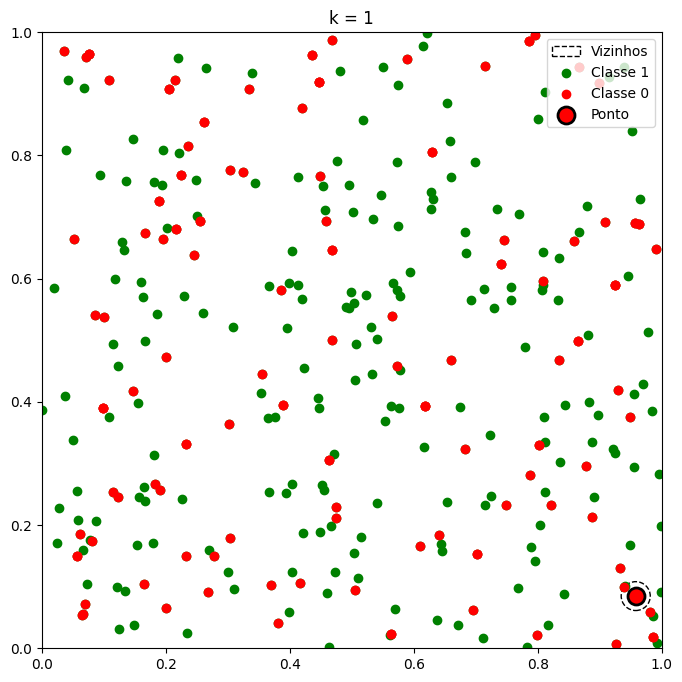

In [ ]:
# Dados
size = 300
x = np.random.rand(size)
y = np.random.rand(size)
X = np.column_stack((x, y))
labels = np.ones(size)
class_0 = np.random.randint(0, size//2)
inx_class_0 = np.random.randint(0, size, class_0)
labels[inx_class_0] = 0

colors = np.array(['green'] * size)
colors[inx_class_0] = 'red'
inx = np.random.randint(0, size)

fig, ax = plt.subplots(figsize=(8,8))

def update(frame):

    ax.clear()
    k = frame

    _, radius = knn_neighboors(x, y, euclidean_dist, inx, k)

    circle = plt.Circle(
        (x[inx], y[inx]),
        radius,
        fill=False,
        linestyle="--",
        color="black",
        label = "Vizinhos"
    )
    ax.add_patch(circle)
    ax.scatter(x, y, color="green", label="Classe 1")
    ax.scatter(
        x[inx_class_0],
        y[inx_class_0],
        color="red",
        label="Classe 0"
    )
    ax.scatter(
        x[inx],
        y[inx],
        color=colors[inx],
        edgecolors='black',
        linewidths=2,
        s=150,
        label="Ponto"
    )
    ax.set_title(f"k = {k}")
    ax.legend()
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)


frames = range(1, size + 1, 10)
ani = FuncAnimation(fig, update, frames=frames, interval=200)
ani.save("knn_vizinhanca.gif", writer="pillow", fps=5)

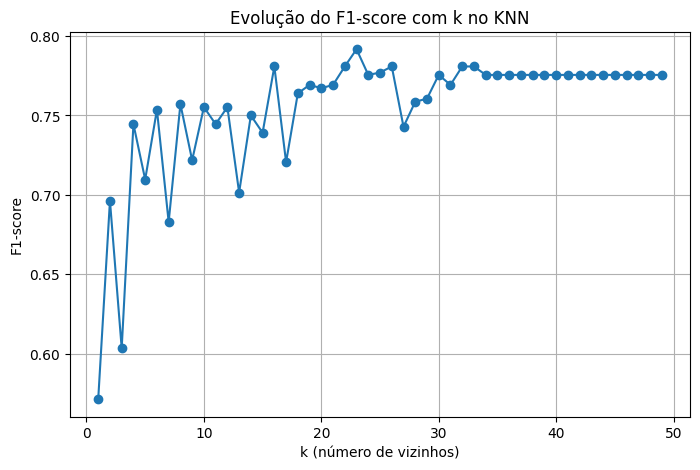

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.3, random_state=42
)

ks = range(1, 50)

f1_scores = []

for k in ks:
    f1 = calculate_f1_score(X_train, X_test, y_train, y_test, k)
    f1_scores.append(f1)

plt.figure(figsize=(8,5))

plt.plot(ks, f1_scores, marker='o')

plt.xlabel("k (número de vizinhos)")
plt.ylabel("F1-score")
plt.title("Evolução do F1-score com k no KNN")

plt.grid(True)
plt.show()

### **Exemplo 2**

In [ ]:
iris_dataset = load_iris(return_X_y=False, as_frame=False)
X = iris_dataset["data"]
y = iris_dataset["target"]